In [1]:
from scripts.GUI import suivi_projet_GUI 

In [2]:
app = suivi_projet_GUI() 
app.mainloop()

Projets pour lesquels il manque l'information de Type / Sujet :
 - PARC - Soutien Parc
Où modifier ? P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/Analyses_budgetaires_categorisation_V20250910.xlsx


# DEBUG

In [4]:
import os
import datetime
import numpy as np
import pandas as pd

from scripts.utils import (
    date_to_str,
    get_last_friday,
    get_all_project_names
)

from scripts.aggregate_individual_data import aggregate_individual_data

from scripts.BDD_update_steps import (
    load_data,
    standardize_pipe,
    update_utils_personne,
    update_utils_contrat,
    update_vision_personne,
    update_vision_contrat,
    save_BDD
)

from scripts.GUI import suivi_projet_GUI 
path_dict = suivi_projet_GUI().PATHS
path_dict

{'root_folder': 'P:/Equipe/Suivi de projet staffing/',
 'agg_backup_rpath': 'Données agrégées',
 'link_rpath': 'Données agrégées/Liens/',
 'bdd_file': 'BDD.xlsx',
 'aggregated_data_file': 'Suivi_Projet_Agrégé.xlsx',
 'projects_info_file': 'ILB_Projects.xlsx',
 'backup_bdd_rpath': 'BACKUPS_BDD/'}

In [ ]:
aggregated_public_archives, agg_log = aggregate_individual_data(path_dict['root_folder'])
print(agg_log)



Fichiers ayant un problème de 'prenom.nom' :
 - 'prenom.nom' ghassen.benhassine trouvé pour ghassen.hassine.ben

Fichiers ayant un problème de projets :
 - 1 projet(s) manquant(s) pour ghassen.hassine.ben


In [7]:
## UPDATING BDD

# LOADING DATA
data = load_data(
    path_dict=path_dict
)

# STANDARDIZE DATA
data, log = standardize_pipe(
    loaded_data=data
)
print('\n'.join(log))

# UPDATE UTILS PERSONNE
utils_personne_new, log = update_utils_personne(
    status_information = data['status_information'], 
    utils_personne_prev = data['bdd_utils_personne']
)
print('\n'.join(log))

# UPDATE UTILS CONTRAT
utils_contrat_new, log = update_utils_contrat(
    budgets_dates_contrats=data['budgets_dates_contrats'], 
    utils_contrat_prev=data['bdd_utils_contrat']
)
print('\n'.join(log))

# UPDATE VISION PERSONNE
vision_personne_new, log = update_vision_personne(
    aggregated_data=data['aggregated_data'], 
    utils_personne=utils_personne_new, 
    utils_contrat=utils_contrat_new, 
    path_dict=path_dict
)
print('\n'.join(log))

# UPDATE VISION CONTRAT
vision_contrat_new = update_vision_contrat(
    vision_personne=vision_personne_new
)

ATTENTION: 1 lignes avec nom de projet erroné (retirées). [nan]
9224 lignes (combinaison personne X date nouvelle) trouvées dans la version précédente de la BDD, mais pas dans les données agrégées, ont été ajoutées.

Aucun changement détecté dans les contrats.
Projets pour lesquels il manque l'information de Type / Sujet :
 - PARC - Soutien Parc
Où modifier ? P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/Analyses_budgetaires_categorisation_V20250910.xlsx


# ANALYSES ANNEXES

In [12]:
from scripts.BDD_update_steps import (
    load_data,
    standardize_pipe,
)

from scripts.utils_analyses_annexes import get_details_about_someone, checking_the_good_labsiens

from scripts.GUI import suivi_projet_GUI 
path_dict = suivi_projet_GUI().PATHS
path_dict

{'root_folder': 'P:/Equipe/Suivi de projet staffing/',
 'agg_backup_rpath': 'Données agrégées',
 'link_rpath': 'Données agrégées/Liens/',
 'bdd_file': 'BDD.xlsx',
 'aggregated_data_file': 'Suivi_Projet_Agrégé.xlsx',
 'projects_info_file': 'ILB_Projects.xlsx',
 'backup_bdd_rpath': 'BACKUPS_BDD/'}

In [19]:
data, log = standardize_pipe(load_data(path_dict))
print('\n\n'.join(log))
      
vision_personne = data['bdd_vision_personne']
vision_contrat = data['bdd_vision_contrat']
utils_personne = data['bdd_utils_personne']
utils_contrat = data['bdd_utils_contrat']

ATTENTION: 1 lignes avec nom de projet erroné (retirées). [nan]

9224 lignes (combinaison personne X date nouvelle) trouvées dans la version précédente de la BDD, mais pas dans les données agrégées, ont été ajoutées.


In [21]:
get_details_about_someone(vision_personne, prenom_nom="martin.recroix", year=2025, month=8)

,h,%
root_name,,
Data - CGDD - Analyse financière du label Greenfin - AVENANT 0,125.5,77.0
Data - Challenge Data - Gestion Challenge,13.0,8.0
ILB - Congés & Arrêts (hors jours fériés),8.0,4.9
ILB - Jour Férié,7.0,4.3
Kanban - Suivi budgétaire projets,3.0,1.8
Labs - Prospection,0.5,0.3
Labs - Réunions internes,5.0,3.1
Labs - Tâches interne (autres),1.0,0.6


Removed: adrien.ferrand, anne.hamon, bertille.tierny, caroline.nguyen, enzo.dalby, gabriel.levy, gabriel.plantier, iker.tardio, ilias.nahmed, jeremy.dreumont, joao.serta, justine.wade, kelly.bourbon, khalid.arjdal, louis.boulanger, luis.campos, marine.grosmaitre, naja.hammad, nestor.toroman, pauline.aumard, philomene.cholet, sophie.fournier, yassine.chafai, youssra.bendjebbar


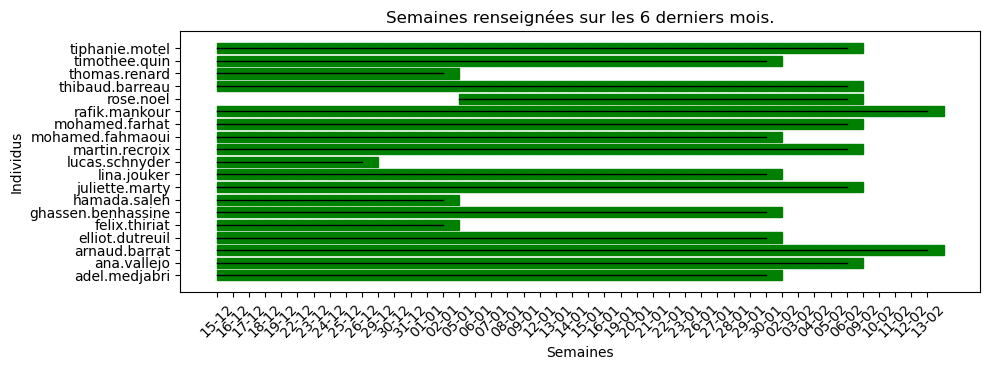

In [22]:
checking_the_good_labsiens(vision_personne, k_months_ago=2)